# Energy Consumption Forecasting Pipeline
### Single Meter | 30-min intervals | Short-term (XGBoost) + Long-term (N-HiTS)

**Pipeline:**
1. Data loading from MongoDB
2. Cleaning & resampling
3. Feature engineering
4. XGBoost - short-term (1–2 days)
5. N-HiTS (NeuralForecast) - long-term (full month ahead)
6. Plots: train/test, residuals, future forecast
7. Anomaly detection

## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from typing import List

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import IsolationForest

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('All imports OK')

## 2. Data Loading

In [ ]:
from pymongo import MongoClient, DESCENDING

MONGO_URI = "string"
DB_NAME = "IOTDeviceMonitor"
COLLECTION = "FUTU00_DataMonitor"
METER_ID = "FUTU0000000004000002"
MODEL_DIR = "./models/"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION]

In [159]:
MODEL_DIR = "E:\Projects\IOT-AI-Implementation\models\M10"

In [ ]:
query = {"EnergymeterId": METER_ID}
cursor = collection.find(query).sort("_id", DESCENDING)
raw = list(cursor)

df_raw = pd.DataFrame(raw)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

## 3. Cleaning & Resampling

In [136]:
df = df_raw.copy()

# Rename
df = df.rename(columns={
    'A1': 'total_kwh',
    'RTC': 'rtc_timestamp',
    'EnergymeterId': 'meter_id'
})

# Sort (VERY IMPORTANT for time series)
df = df.sort_values(['meter_id', 'rtc_timestamp'])
                    
# Type conversion
df['total_kwh'] = pd.to_numeric(df['total_kwh'], errors='coerce')
df['rtc_timestamp'] = pd.to_datetime(df['rtc_timestamp'], errors='coerce')

# Drop rows with no timestamp or energy
df = df.dropna(subset=['rtc_timestamp', 'total_kwh'])

# Remove zeros (meter off / invalid)
df.loc[df['total_kwh'] == 0, 'total_kwh'] = np.nan
df = df.dropna()

# Resample to 1h
numeric_cols = df.select_dtypes(include=[np.number]).columns

df = (
    df.set_index('rtc_timestamp')
      .resample('1h')['total_kwh']
      .mean()
      .reset_index()
)

# Fill small gaps (up to 2 missing = 1 hour) via interpolation
# df = df.interpolate(method='time', limit=1)
# df = df.reset_index(name='total_kwh')

print(f"After cleaning: {df.shape}")
print(f"Date range: {df['rtc_timestamp'].min()} → {df['rtc_timestamp'].max()}")
df.head()

After cleaning: (12989, 2)
Date range: 2024-10-16 04:00:00 → 2026-04-10 08:00:00


,rtc_timestamp,total_kwh
0,2024-10-16 04:00:00,79909.906296
1,2024-10-16 05:00:00,79932.895857
2,2024-10-16 06:00:00,79960.611061
3,2024-10-16 07:00:00,79978.275606
4,2024-10-16 08:00:00,80008.227973


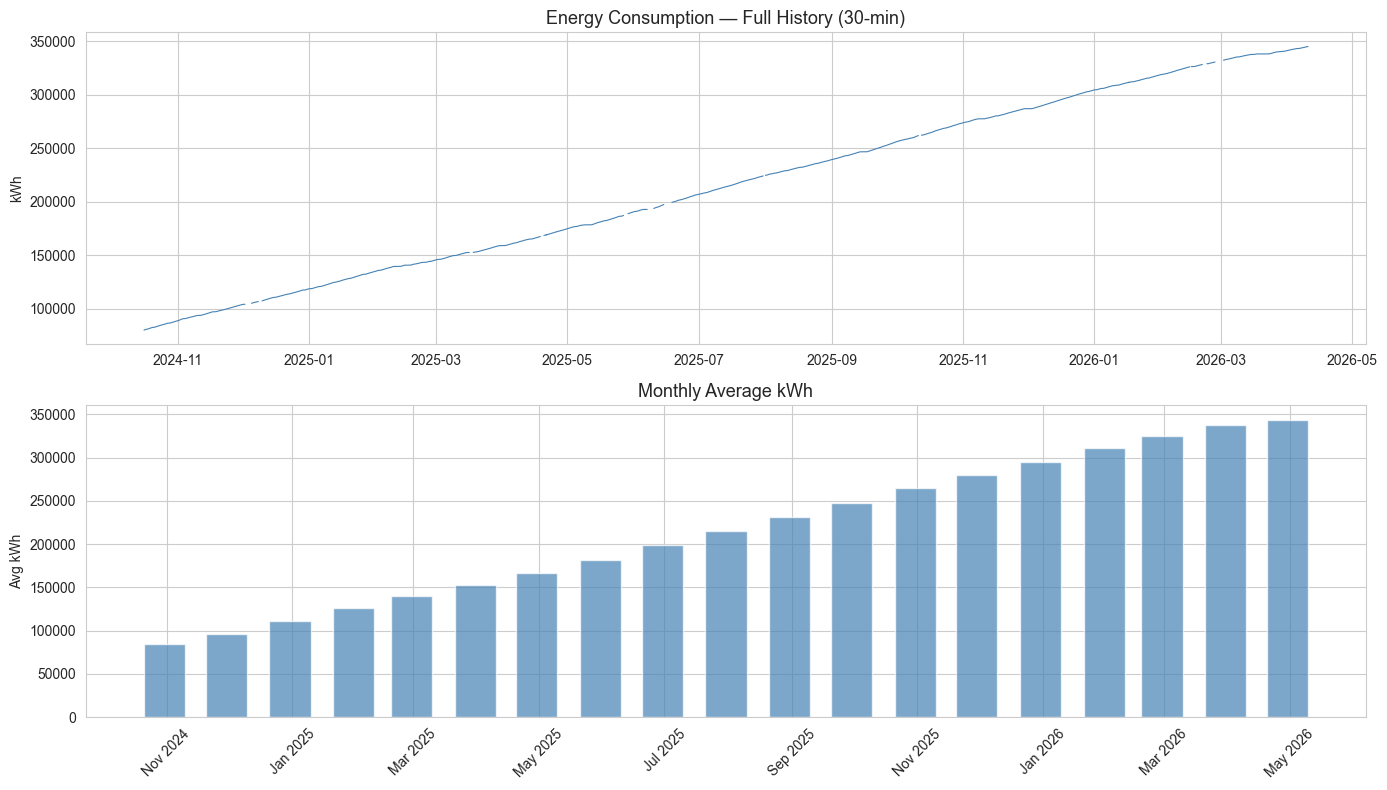

In [137]:
# Plot raw cleaned data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['rtc_timestamp'], df['total_kwh'], linewidth=0.8, color='steelblue')
axes[0].set_title('Energy Consumption — Full History (30-min)')
axes[0].set_ylabel('kWh')

# Monthly averages
monthly = df.set_index('rtc_timestamp')['total_kwh'].resample('ME').mean()
axes[1].bar(monthly.index, monthly.values, width=20, color='steelblue', alpha=0.7)
axes[1].set_title('Monthly Average kWh')
axes[1].set_ylabel('Avg kWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [138]:
# Basic stats
print(df['total_kwh'].describe())

# Missing % after resample
full_range = pd.date_range(df['rtc_timestamp'].min(), df['rtc_timestamp'].max(), freq='1h')
missing_pct = (1 - len(df) / len(full_range)) * 100
print(f"\nMissing 1h slots: {missing_pct:.2f}%")

count     12350.000000
mean     215022.002614
std       78897.998557
min       79909.906296
25%      144236.025453
50%      216289.933403
75%      285145.645447
max      345251.152727
Name: total_kwh, dtype: float64

Missing 1h slots: 0.00%


## 4. Feature Engineering

In [139]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Time features
    out['hour_of_day'] = out['rtc_timestamp'].dt.hour
    out['day_of_week'] = out['rtc_timestamp'].dt.dayofweek
    # out['month'] = out['rtc_timestamp'].dt.month
    out['rolling_max_6'] = out['total_kwh'].rolling(6).max().reset_index(level=0, drop=True)
    out['rolling_min_6'] = out['total_kwh'].rolling(6).min().reset_index(level=0, drop=True)
    out['rolling_range_6'] = out['rolling_max_6'] - out['rolling_min_6']
    # out['is_weekend'] = (out['day_of_week'] >= 5).astype(int)

    # Cyclical encoding (captures periodicity without ordinal bias)
    out['hour_sin'] = np.sin(2 * np.pi * out['hour_of_day'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour_of_day'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['day_of_week'] / 7)

    # Lag features
    for lag in [1, 2, 3, 6, 12, 24]:   
        out[f'kwh_lag_{lag}'] = out['total_kwh'].shift(lag)
        
    out['target_diff'] = out['total_kwh'] - out['kwh_lag_1'] 
    out = out[out['target_diff'].abs() > 1]        

    # # Same hour yesterday and last week
    # out['kwh_lag_96'] = out['total_kwh'].shift(96)    # 24h ago
    # out['kwh_lag_672'] = out['total_kwh'].shift(672)   # 7 days ago

    # Rolling features
    for w in [3, 6, 24]:
        # out[f'kwh_roll_mean_{w}'] = out['total_kwh'].rolling(w, min_periods=1).mean()
        out[f'kwh_roll_std_{w}'] = out['total_kwh'].rolling(w, min_periods=2).std()
        # out[f'kwh_roll_max_{w}'] = out['total_kwh'].rolling(w, min_periods=1).max()

    # Diff features
    out['diff_2'] = out['total_kwh'].diff(2)
    # out['diff_4'] = out['total_kwh'].diff(4)   # 1-hour diff
    # out['diff_96']= out['total_kwh'].diff(96)  # 24-hour diff

    return out


feat_df = build_features(df)
feat_df = feat_df.dropna().reset_index(drop=True)

print(f"Feature df shape: {feat_df.shape}")
feat_df.head()

Feature df shape: (10096, 22)


,rtc_timestamp,total_kwh,hour_of_day,day_of_week,rolling_max_6,rolling_min_6,rolling_range_6,hour_sin,hour_cos,dow_sin,dow_cos,kwh_lag_1,kwh_lag_2,kwh_lag_3,kwh_lag_6,kwh_lag_12,kwh_lag_24,target_diff,kwh_roll_std_3,kwh_roll_std_6,kwh_roll_std_24,diff_2
0,2024-10-17 04:00:00,80518.441618,4,3,80518.441618,80437.611129,80.830489,0.866025,5.000000e-01,0.433884,-0.900969,80514.310000,80514.310000,80507.869867,80412.541622,80223.475600,79909.906296,4.131618,5.327718,44.302810,193.821698,10.571751
1,2024-10-17 05:00:00,80530.727361,5,3,80530.727361,80470.285522,60.441839,0.965926,2.588190e-01,0.433884,-0.900969,80518.441618,80514.310000,80514.310000,80437.611129,80259.587222,79932.895857,12.285743,8.539511,35.368078,199.091950,16.417361
2,2024-10-17 06:00:00,80532.190000,6,3,80532.190000,80507.869867,24.320133,1.000000,6.123234e-17,0.433884,-0.900969,80530.727361,80518.441618,80514.310000,80470.285522,80296.211429,79960.611061,1.462639,7.550903,22.635289,195.801399,13.748382
3,2024-10-17 08:00:00,80534.135556,8,3,80534.135556,80514.310000,19.825556,0.866025,-5.000000e-01,0.433884,-0.900969,80532.190000,80532.190000,80530.727361,80514.310000,80359.513175,80008.227973,1.945556,1.709790,10.893732,191.352322,3.408194
4,2024-10-17 09:00:00,80558.084265,9,3,80558.084265,80518.441618,39.642647,0.707107,-7.071068e-01,0.433884,-0.900969,80534.135556,80532.190000,80532.190000,80514.310000,80385.507463,80040.995915,23.948709,14.421274,15.365897,186.311451,25.894265


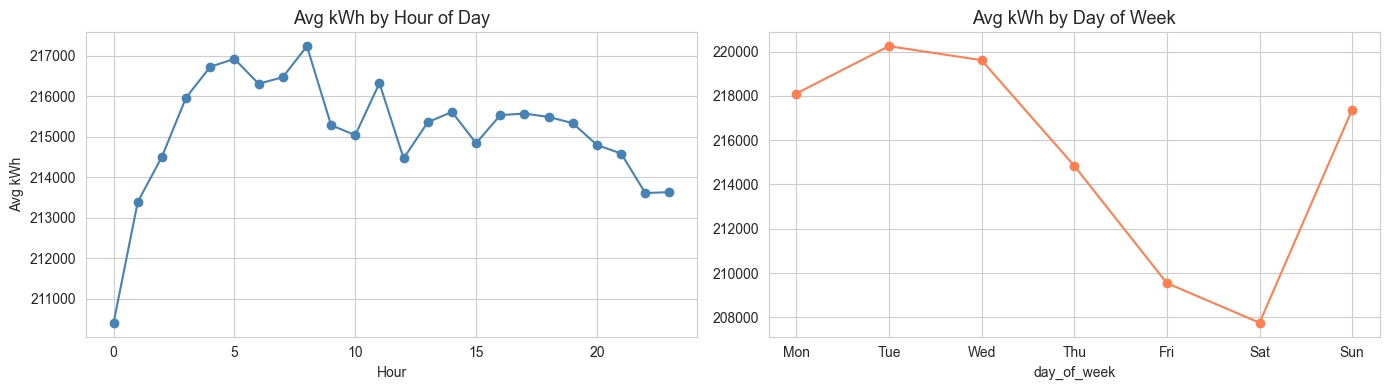

In [140]:
# Hourly & weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_df.groupby('hour_of_day')['total_kwh'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Avg kWh by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg kWh')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
feat_df.groupby('day_of_week')['total_kwh'].mean().plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Avg kWh by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)

plt.tight_layout()
plt.show()

In [141]:
feat_df.columns

Index(['rtc_timestamp', 'total_kwh', 'hour_of_day', 'day_of_week',
       'rolling_max_6', 'rolling_min_6', 'rolling_range_6', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_3',
       'kwh_lag_6', 'kwh_lag_12', 'kwh_lag_24', 'target_diff',
       'kwh_roll_std_3', 'kwh_roll_std_6', 'kwh_roll_std_24', 'diff_2'],
      dtype='str')

## 5. Train / Test Split

In [142]:
TARGET = 'target_diff'

EXCLUDED = {
    'rtc_timestamp', 'total_kwh',
    'hour_of_day', 'day_of_week',  # kept cyclical versions
    'kwh_roll_mean_3', 'kwh_roll_mean_6', 'kwh_roll_mean_24', 'target_diff'
}

model_features = [c for c in feat_df.columns if c not in EXCLUDED]

# Chronological 80/20 split
split_idx = int(len(feat_df) * 0.8)
train_df  = feat_df.iloc[:split_idx].copy()
test_df   = feat_df.iloc[split_idx:].copy()

X_train = train_df[model_features]
y_train = train_df[TARGET]
X_test  = test_df[model_features]
y_test  = test_df[TARGET]

print(f"Train: {train_df['rtc_timestamp'].min()} → {train_df['rtc_timestamp'].max()} | {len(train_df):,} rows")
print(f"Test:  {test_df['rtc_timestamp'].min()} → {test_df['rtc_timestamp'].max()} | {len(test_df):,} rows")
print(f"Features: {len(model_features)}")

Train: 2024-10-17 04:00:00 → 2025-12-16 21:00:00 | 8,076 rows
Test:  2025-12-16 22:00:00 → 2026-04-10 08:00:00 | 2,020 rows
Features: 17


In [143]:
X_train.nunique().sort_values()

dow_cos               7
dow_sin               7
hour_sin             21
hour_cos             22
kwh_lag_24         7232
kwh_lag_12         7519
kwh_lag_6          7786
rolling_min_6      7833
kwh_lag_3          7937
kwh_lag_2          8009
rolling_max_6      8076
rolling_range_6    8076
kwh_lag_1          8076
kwh_roll_std_3     8076
kwh_roll_std_6     8076
kwh_roll_std_24    8076
diff_2             8076
dtype: int64

In [144]:
y_train.describe()

count    8076.000000
mean       24.974420
std         8.079152
min         1.000145
25%        20.332684
50%        24.147060
75%        30.168424
max        63.685547
Name: target_diff, dtype: float64

## 6. XGBoost Model — Short-term Forecasting

In [145]:
# explicitly define which columns go into the model
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features

['rolling_max_6',
 'rolling_min_6',
 'rolling_range_6',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'kwh_lag_1',
 'kwh_lag_2',
 'kwh_lag_3',
 'kwh_lag_6',
 'kwh_lag_12',
 'kwh_lag_24',
 'kwh_roll_std_3',
 'kwh_roll_std_6',
 'kwh_roll_std_24',
 'diff_2']

In [146]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)
    ],
    remainder='drop' # Drops unused columns
)

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=800,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
    ))
])

xgb_model.fit(X_train, y_train)
print('XGBoost training complete')

XGBoost training complete


In [147]:
# Predictions
delta_pred = xgb_model.predict(X_test)
y_pred = X_test['kwh_lag_1'].values + delta_pred
y_pred = pd.DataFrame(y_pred, columns=['total_kwh'], index=X_test.index)
y_pred.head()

,total_kwh
8076,295827.388340
8077,295858.821192
8078,295891.567042
8079,295922.740388
8080,295954.819059


In [148]:
# Metrics
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in actual.columns:
        mae = mean_absolute_error(actual[col], predicted[col])
        rmse = root_mean_squared_error(actual[col], predicted[col])
        mape = np.mean(np.abs((actual[col] - predicted[col]) / np.clip(actual[col], 1e-6, None))) * 100
        rows.append({'target': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(rows).sort_values('RMSE')

y_test_actual = test_df['total_kwh'].loc[X_test.index]
metrics_df = regression_metrics(y_test_actual.to_frame(), y_pred)
metrics_df

,target,MAE,RMSE,MAPE_pct
0,total_kwh,1.846042,2.718667,0.000574


## 7. Plots — Training, Testing, Residuals

In [149]:
# Reconstruct predictions for plotting
delta_train = xgb_model.predict(X_train)
y_train_reconstructed = X_train['kwh_lag_1'].values + delta_train

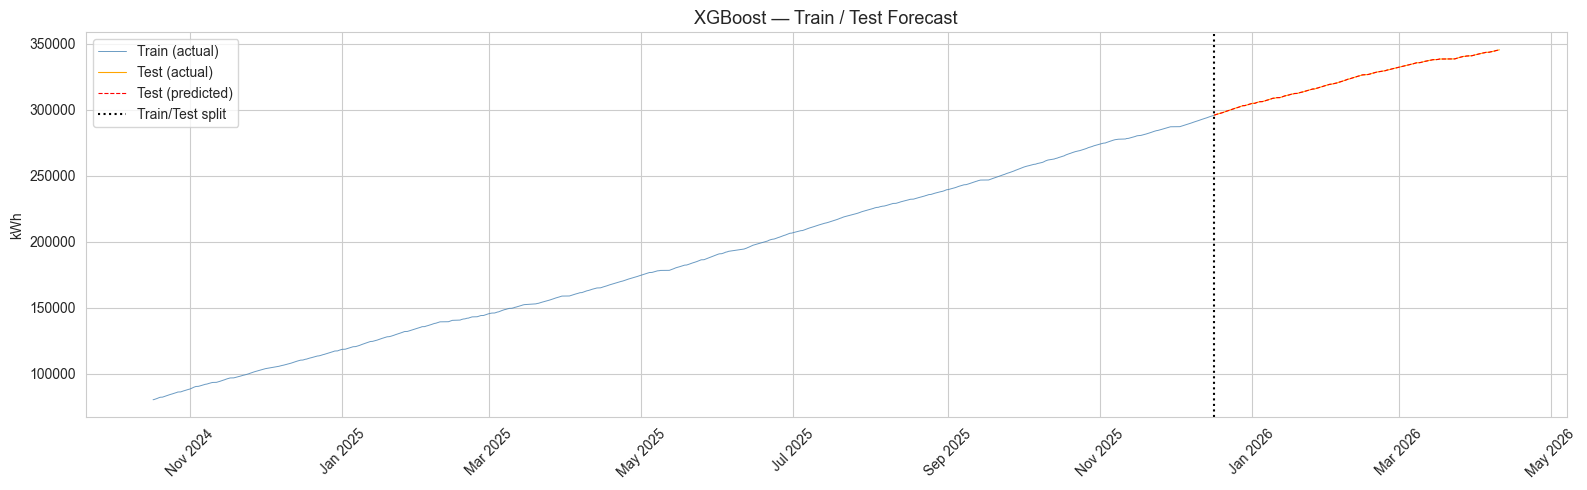

In [150]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df['rtc_timestamp'], y_train_reconstructed,          # ← reconstructed, not y_train
        label='Train (actual)', color='steelblue', linewidth=0.7, alpha=0.8)
ax.plot(test_df['rtc_timestamp'], y_test_actual.values,
        label='Test (actual)', color='orange', linewidth=0.8)
ax.plot(test_df['rtc_timestamp'], y_pred['total_kwh'].values,
        label='Test (predicted)', color='red', linewidth=0.8, linestyle='--')
ax.axvline(test_df['rtc_timestamp'].iloc[0], color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('XGBoost — Train / Test Forecast')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

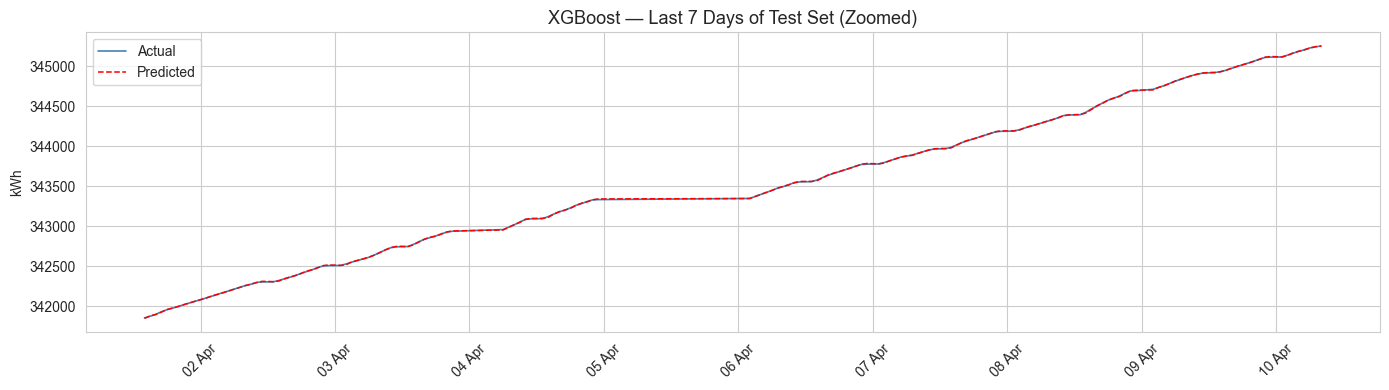

In [151]:
# Zoom into last 7 days of test
last7 = test_df.tail(24 * 7)   # 24 steps/day for 1h intervals, not 96
pred_last7 = y_pred['total_kwh'].iloc[-len(last7):]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last7['rtc_timestamp'], last7['total_kwh'],      
        label='Actual', color='steelblue', linewidth=1.2)
ax.plot(last7['rtc_timestamp'], pred_last7.values,      
        label='Predicted', color='red', linewidth=1.1, linestyle='--')
ax.set_title('XGBoost — Last 7 Days of Test Set (Zoomed)')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

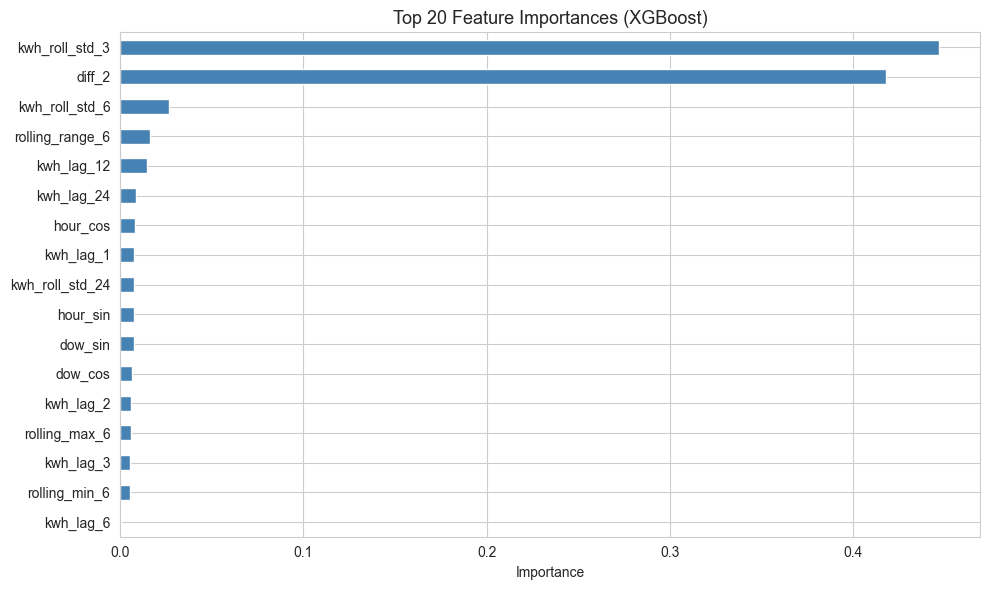

In [154]:
# Feature Importance
booster = xgb_model.named_steps['model']
feat_imp = pd.Series(booster.feature_importances_, index=model_features)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Anomaly Detection

In [156]:
results = test_df[['rtc_timestamp', 'total_kwh']].copy()
results['predicted'] = y_pred['total_kwh'].values        # y_pred is a DataFrame
results['residual'] = results['total_kwh'] - results['predicted']
resid_std = results['residual'].std()
results['z_score'] = results['residual'] / resid_std

# Isolation Forest on residuals
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
results['iso_flag']  = iso.fit_predict(results[['residual']])
results['iso_score'] = iso.decision_function(results[['residual']])

# Rule-based: |z| > 3
results['rule_flag'] = (results['z_score'].abs() > 3).astype(int)
results['anomaly']   = ((results['iso_flag'] == -1) | (results['rule_flag'] == 1)).astype(int)
results['severity']  = results['z_score'].abs().round(3)

anomalies = results[results['anomaly'] == 1].sort_values('severity', ascending=False)
print(f"Anomalies detected: {len(anomalies)} / {len(results)} ({100*len(anomalies)/len(results):.1f}%)")
anomalies.head(10)

Anomalies detected: 61 / 2020 (3.0%)


,rtc_timestamp,total_kwh,predicted,residual,z_score,iso_flag,iso_score,rule_flag,anomaly,severity
8721,2026-01-17 11:00:00,311811.068125,311832.204409,-21.136284,-7.802924,-1,-0.138638,1,1,7.803
9350,2026-02-16 23:00:00,326715.920000,326731.627191,-15.707191,-5.798655,-1,-0.133187,1,1,5.799
8722,2026-01-17 12:00:00,311835.168788,311849.543944,-14.375156,-5.306905,-1,-0.128043,1,1,5.307
9345,2026-02-16 18:00:00,326652.692424,326665.231590,-12.539166,-4.629109,-1,-0.115194,1,1,4.629
9441,2026-02-23 22:00:00,329703.890140,329716.340795,-12.450655,-4.596433,-1,-0.113603,1,1,4.596
9440,2026-02-23 21:00:00,329685.318052,329673.334611,11.983442,4.423951,-1,-0.097345,1,1,4.424
9916,2026-03-31 23:00:00,341616.480000,341627.962195,-11.482195,-4.238905,-1,-0.103860,1,1,4.239
9763,2026-03-17 18:00:00,338300.440000,338311.686876,-11.246876,-4.152031,-1,-0.098903,1,1,4.152
8573,2026-01-09 05:00:00,308415.637260,308404.700510,10.936751,4.037542,-1,-0.092173,1,1,4.038
8950,2026-01-28 16:00:00,317134.879273,317145.795027,-10.915754,-4.029791,-1,-0.093463,1,1,4.030


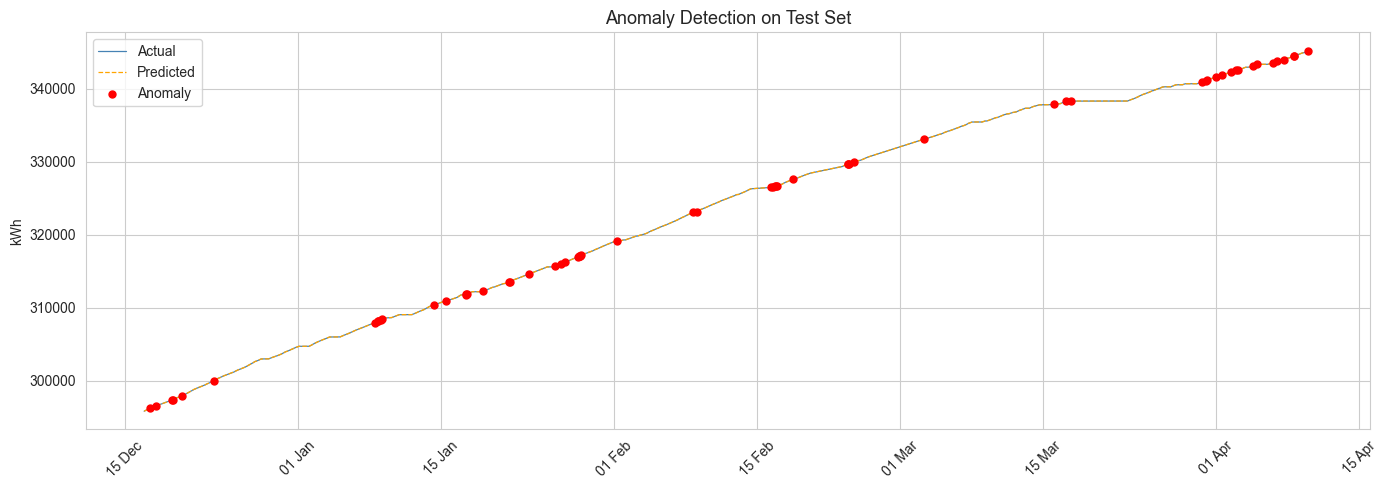

In [158]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['rtc_timestamp'], results['total_kwh'], label='Actual', linewidth=0.9, color='steelblue')
ax.plot(results['rtc_timestamp'], results['predicted'], label='Predicted', linewidth=0.9, color='orange', linestyle='--')
ax.scatter(anomalies['rtc_timestamp'], anomalies['total_kwh'], color='red', s=25, zorder=5, label='Anomaly')
ax.set_title('Anomaly Detection on Test Set')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Save XGBoost Model

In [160]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb_model, f"{MODEL_DIR}/xgb_energy_model.pkl")
joblib.dump(model_features, f"{MODEL_DIR}/model_features.pkl")

print('XGBoost model saved.')

XGBoost model saved.


## 10. PENDING FROM HERE: N-HiTS - Long-term Future Forecasting (May 2026)

> **N-HiTS** (Neural Hierarchical Interpolation for Time Series) is designed for long-horizon forecasting.  
> It predicts the full future window in **one shot** — no recursive error accumulation.

In [165]:

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE

FORECAST_HORIZON = 24 * 31    # 31 days × 24h = 744 steps  (was 96*31 = wrong, 15-min)
INPUT_SIZE = 24 * 14    # look back 2 weeks = 336h    (was 96*14)

nf_df = df[['rtc_timestamp', 'total_kwh']].copy()
nf_df = nf_df.dropna(subset=['rtc_timestamp', 'total_kwh'])
nf_df.loc[nf_df['total_kwh'] == 0, 'total_kwh'] = np.nan

nf_df.columns = ['ds', 'y']
nf_df['unique_id'] = METER_ID
nf_df = nf_df[['unique_id', 'ds', 'y']]

print(f"NeuralForecast df shape: {nf_df.shape}")
nf_df.head()

NeuralForecast df shape: (12350, 3)


,unique_id,ds,y
0,FUTU0000000004000002,2024-10-16 04:00:00,79909.906296
1,FUTU0000000004000002,2024-10-16 05:00:00,79932.895857
2,FUTU0000000004000002,2024-10-16 06:00:00,79960.611061
3,FUTU0000000004000002,2024-10-16 07:00:00,79978.275606
4,FUTU0000000004000002,2024-10-16 08:00:00,80008.227973


In [167]:
# Train / val split for NeuralForecast (last HORIZON rows as validation)
nf_train = nf_df.iloc[:-FORECAST_HORIZON].copy()
nf_val   = nf_df.iloc[-FORECAST_HORIZON:].copy()

print(f"NF Train: {nf_train['ds'].min()} → {nf_train['ds'].max()}")
print(f"NF Val: {nf_val['ds'].min()} → {nf_val['ds'].max()}")

NF Train: 2024-10-16 04:00:00 → 2026-03-10 08:00:00
NF Val: 2026-03-10 09:00:00 → 2026-04-10 08:00:00


In [191]:
nhits = NHITS(
    h=FORECAST_HORIZON,
    input_size=INPUT_SIZE,
    loss=MAE(),
    max_steps=1000,
    batch_size=32,
    early_stop_patience_steps=0,
    val_check_steps=50,
    scaler_type='standard',
    n_freq_downsample=[24, 4, 1]   # hierarchical: day / 4h / 1h
)

nf = NeuralForecast(models=[nhits], freq='h')   # was '15min' — wrong
nf.fit(df=nf_train, val_size=FORECAST_HORIZON)
print('N-HiTS training complete')

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.7 M  | train | 0    
---------------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.878    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  7.67it/s, v_num=2, train_loss_step=0.338, train_loss_epoch=0.338, valid_loss=1.29e+3]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  7.50it/s, v_num=2, train_loss_step=0.338, train_loss_epoch=0.338, valid_loss=1.29e+3]
N-HiTS training complete


In [192]:
# Validate on held-out period
val_preds = nf.predict()
val_preds.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 199.72it/s]


,unique_id,ds,NHITS
0,FUTU0000000004000002,2026-03-10 09:00:00,336461.40625
1,FUTU0000000004000002,2026-03-10 10:00:00,336520.28125
2,FUTU0000000004000002,2026-03-10 11:00:00,336531.15625
3,FUTU0000000004000002,2026-03-10 12:00:00,336555.00000
4,FUTU0000000004000002,2026-03-10 13:00:00,336590.84375


In [193]:
# Validation metrics
merged = nf_val.merge(val_preds[['unique_id', 'ds', 'NHITS']], on=['unique_id', 'ds'], how='inner')

nhits_mae  = mean_absolute_error(merged['y'], merged['NHITS'])
nhits_rmse = root_mean_squared_error(merged['y'], merged['NHITS'])
nhits_mape = np.mean(np.abs((merged['y'] - merged['NHITS']) / np.clip(merged['y'], 1e-6, None))) * 100

print(f"N-HiTS Validation MAE : {nhits_mae:.4f} kWh")
print(f"N-HiTS Validation RMSE : {nhits_rmse:.4f} kWh")
print(f"N-HiTS Validation MAPE : {nhits_mape:.2f}%")

N-HiTS Validation MAE : 8800.9722 kWh
N-HiTS Validation RMSE : 10087.9892 kWh
N-HiTS Validation MAPE : 2.58%


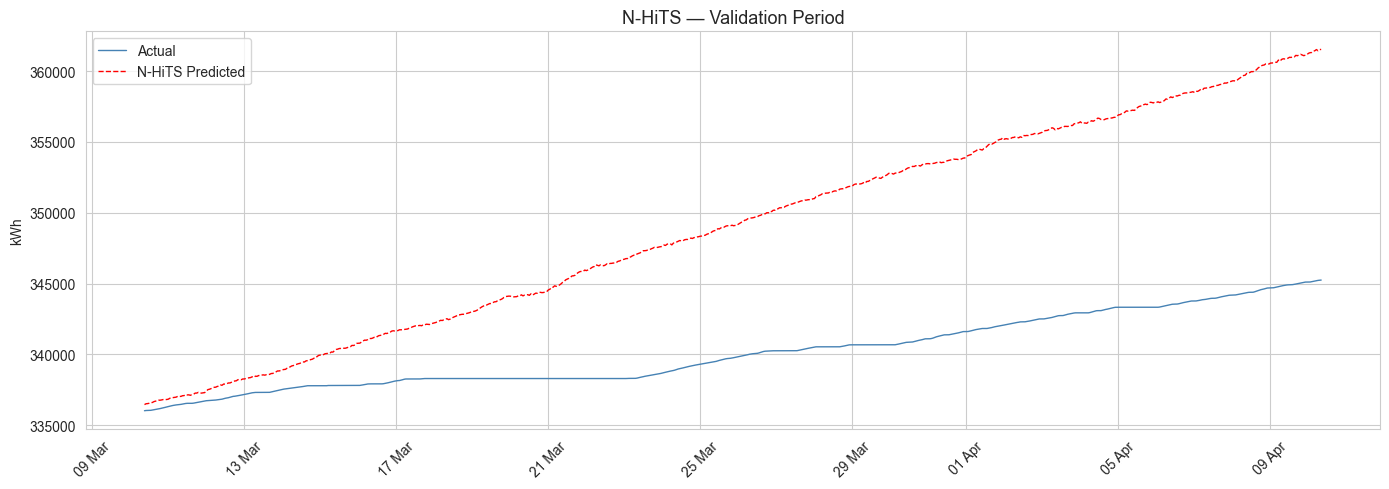

In [194]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'], label='Actual', color='steelblue', linewidth=1)
ax.plot(merged['ds'], merged['NHITS'], label='N-HiTS Predicted', color='red', linewidth=1, linestyle='--')
ax.set_title('N-HiTS — Validation Period')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Forecast Future — May 2026

In [195]:
# Retrain on FULL data before forecasting future
nf_full = NeuralForecast(models=[nhits], freq='h')  
nf_full.fit(df=nf_df)

future_forecast = nf_full.predict()
future_forecast = future_forecast.rename(columns={'NHITS': 'forecast_kwh'})
future_forecast['forecast_kwh'] = future_forecast['forecast_kwh'].clip(lower=0)

print(f"Future forecast: {future_forecast['ds'].min()} → {future_forecast['ds'].max()}")
future_forecast.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.7 M  | train | 0    
---------------------------------------------------------------
3.7 M     Trainable params
0         Non-trainable params
3.7 M     Total params
14.878    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  8.03it/s, v_num=4, train_loss_step=0.298, train_loss_epoch=0.298]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  7.90it/s, v_num=4, train_loss_step=0.298, train_loss_epoch=0.298]

GPU available: False, used: False


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 199.89it/s]
Future forecast: 2026-04-10 09:00:00 → 2026-05-11 08:00:00


,unique_id,ds,forecast_kwh
0,FUTU0000000004000002,2026-04-10 09:00:00,345308.25000
1,FUTU0000000004000002,2026-04-10 10:00:00,345294.56250
2,FUTU0000000004000002,2026-04-10 11:00:00,345329.21875
3,FUTU0000000004000002,2026-04-10 12:00:00,345337.03125
4,FUTU0000000004000002,2026-04-10 13:00:00,345378.37500


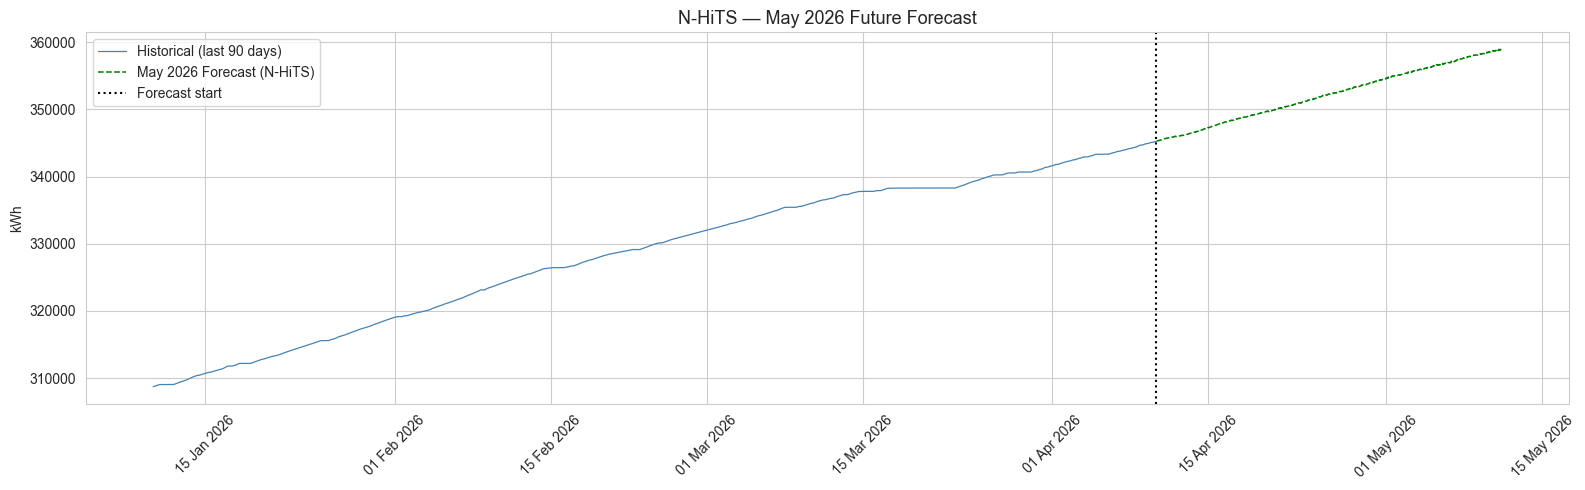

In [196]:
# Plot: history + future forecast
last_90d = nf_df[nf_df['ds'] >= nf_df['ds'].max() - pd.Timedelta(days=90)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(last_90d['ds'], last_90d['y'], label='Historical (last 90 days)', color='steelblue', linewidth=0.9)
ax.plot(future_forecast['ds'], future_forecast['forecast_kwh'],
        label='May 2026 Forecast (N-HiTS)', color='green', linewidth=1.1, linestyle='--')
ax.axvline(nf_df['ds'].max(), color='black', linewidth=1.5, linestyle=':', label='Forecast start')
ax.set_title('N-HiTS — May 2026 Future Forecast')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

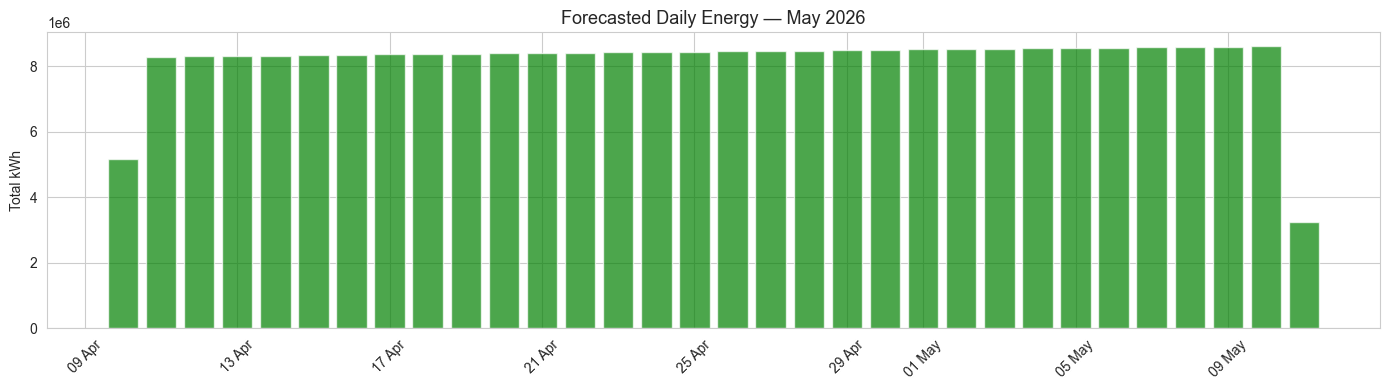

Total forecasted energy for May 2026: 262044512.00 kWh


In [197]:
# Daily aggregated forecast for May
daily_forecast = (
    future_forecast.set_index('ds')['forecast_kwh']
    .resample('D').sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_forecast['ds'], daily_forecast['forecast_kwh'], color='green', alpha=0.7, width=0.8)
ax.set_title('Forecasted Daily Energy — May 2026')
ax.set_ylabel('Total kWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total forecasted energy for May 2026: {daily_forecast['forecast_kwh'].sum():.2f} kWh")

In [198]:
# Compare model summaries
summary = pd.DataFrame([
    {'Model': 'XGBoost (1-step)', 'MAE': metrics_df["MAE"], 'RMSE': metrics_df["RMSE"], 'MAPE%': metrics_df["MAPE_pct"],
     'Use case': 'Next 1h to 1-2 days'},           
    {'Model': 'N-HiTS', 'MAE': nhits_mae, 'RMSE': nhits_rmse, 'MAPE%': nhits_mape,
     'Use case': 'Next 1 month (May 2026)'}
])
summary.round(4)

,Model,MAE,RMSE,MAPE%,Use case
0,XGBoost (1-step),"0 1.846042 Name: MAE, dtype: float64","0 2.718667 Name: RMSE, dtype: float64","0 0.000574 Name: MAPE_pct, dtype: float64",Next 1h to 1-2 days
1,N-HiTS,8800.972151,10087.989154,2.57743,Next 1 month (May 2026)


In [199]:
# Save future forecast
future_forecast.to_csv(f"{MODEL_DIR}/may_2026_forecast.csv", index=False)
nf_full.save(f"{MODEL_DIR}/nhits_model", overwrite=True)
print('N-HiTS model and forecast saved.')

N-HiTS model and forecast saved.


## 12. XGBoost Recursive - Short-term Future (1–2 days ahead)

> Use this for next-day operations where accuracy matters more than horizon length.

In [ ]:
def forecast_recursive(model, feat_df: pd.DataFrame, steps: int = 24) -> pd.DataFrame:
    """
    Recursive 1-step-at-a-time forecasting using XGBoost.
    steps=24 → next 24 hours (1h intervals)
    """
    history = feat_df.copy()
    preds   = []
    last_ts = history['rtc_timestamp'].iloc[-1]

    for _ in range(steps):
        next_ts = last_ts + pd.Timedelta(hours=1)     
        row = {}

        # Time features
        row['hour_sin'] = np.sin(2 * np.pi * next_ts.hour / 24)
        row['hour_cos'] = np.cos(2 * np.pi * next_ts.hour / 24)
        row['dow_sin'] = np.sin(2 * np.pi * next_ts.dayofweek / 7)
        row['dow_cos'] = np.cos(2 * np.pi * next_ts.dayofweek / 7)
        row['mon_sin'] = np.sin(2 * np.pi * next_ts.month / 12)
        row['mon_cos'] = np.cos(2 * np.pi * next_ts.month / 12)
        row['is_weekend'] = int(next_ts.dayofweek >= 5)

        # Lag features (1h intervals)
        for lag in [1, 2, 3, 4, 6, 8, 12, 24, 48, 96]:   # 96 = 4 days back, fine
            row[f'kwh_lag_{lag}'] = history['total_kwh'].iloc[-lag] if lag <= len(history) else np.nan
        row['kwh_lag_168'] = history['total_kwh'].iloc[-168] if 168 <= len(history) else np.nan  

        # Rolling features (1h intervals)
        for w in [4, 8, 24, 96]:
            slice_ = history['total_kwh'].iloc[-w:]
            row[f'kwh_roll_mean_{w}'] = slice_.mean()
            row[f'kwh_roll_std_{w}']  = slice_.std()
            row[f'kwh_roll_max_{w}']  = slice_.max()

        # Diff features
        row['diff_1']  = history['total_kwh'].iloc[-1] - history['total_kwh'].iloc[-2]
        row['diff_4']  = history['total_kwh'].iloc[-1] - history['total_kwh'].iloc[-5]
        row['diff_96'] = history['total_kwh'].iloc[-1] - history['total_kwh'].iloc[-97] if len(history) > 97 else 0

        X_row    = pd.DataFrame([row])[model_features]
        pred_kwh = float(model.predict(X_row)[0])
        pred_kwh = max(pred_kwh, 0)

        preds.append({'rtc_timestamp': next_ts, 'total_kwh': pred_kwh})

        new_row = pd.DataFrame([{'rtc_timestamp': next_ts, 'total_kwh': pred_kwh}])
        history = pd.concat([history[['rtc_timestamp', 'total_kwh']], new_row], ignore_index=True)
        last_ts = next_ts

    return pd.DataFrame(preds)


# Forecast next 48 hours
next_48h = forecast_recursive(xgb_model, feat_df, steps=24 * 2)  

fig, ax = plt.subplots(figsize=(14, 4))
last_3d = feat_df.tail(24 * 3)                                    
ax.plot(last_3d['rtc_timestamp'], last_3d['total_kwh'], label='Historical (last 3 days)', color='steelblue')
ax.plot(next_48h['rtc_timestamp'], next_48h['total_kwh'], label='XGBoost Next 48h', color='red', linestyle='--')
ax.axvline(feat_df['rtc_timestamp'].iloc[-1], color='black', linestyle=':', linewidth=1.5)
ax.set_title('XGBoost Recursive — Next 48 Hours')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()